# Econometric Theory & ML

This notebook loads the provided kindergarten dataset, performs EDA, fits at least five models for **score_read** and **score_math**, selects a final model via cross-validation, reports inference/diagnostics, and computes the **out-of-sample MSE** `mse_out` exactly as required.

> Replace `xxx` in the file name with your group name (or student ID if solo) before submission.

In [ ]:
import pandas as pd
import numpy as np

# load data (as per brief)
sample_url = "https://drive.google.com/uc?export=download&id=1ekCjJOTjGD0OASErwVnwhJuPD0hFfCEF"
out_url = sample_url  # will be replaced by markers at grading time

db_sample = pd.read_csv(sample_url)
db_out = pd.read_csv(out_url)

print("Sample shape:", db_sample.shape, "| Out shape:", db_out.shape)
display(db_sample.head())

Sample shape: (5060, 14) | Out shape: (5060, 14)


,score_read,score_math,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
0,474.0,602.0,male,1980 Q2,free,cauc,small,rural,master,level1,6.0,cauc,36.0,72.0
1,403.0,434.0,male,1980 Q3,free,afam,small,rural,bachelor,apprentice,1.0,cauc,24.0,57.0
2,455.0,520.0,male,1980 Q2,non-free,cauc,regular+aide,suburban,bachelor,level1,5.0,afam,22.0,51.0
3,405.0,454.0,female,1979 Q4,free,cauc,regular+aide,rural,bachelor,level1,11.0,cauc,4.0,6.0
4,433.0,473.0,female,1980 Q3,non-free,cauc,regular,rural,bachelor,level1,2.0,cauc,40.0,76.0



Dtypes:
 score_read           float64
score_math           float64
gender                object
birth                 object
lunch                 object
ethnicity             object
class_type            object
school                object
degree                object
ladder                object
experience           float64
t_ethnicity           object
schooldistrict_id    float64
school_id            float64
dtype: object

Missing (count):
 score_read           417
score_math           354
gender                 0
birth                  5
lunch                 21
ethnicity              1
class_type             0
school                 0
degree                19
ladder               511
experience            19
t_ethnicity           52
schooldistrict_id      0
school_id              0
dtype: int64


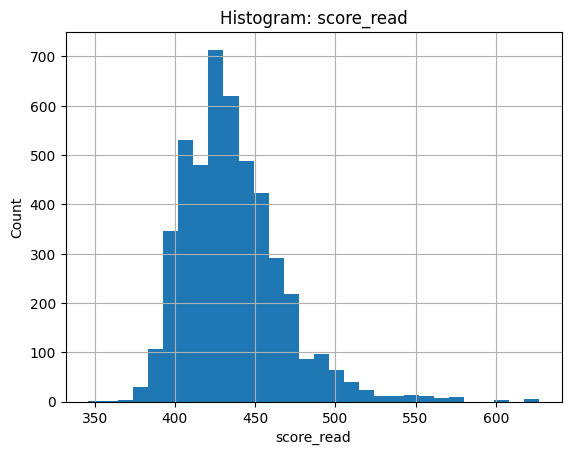

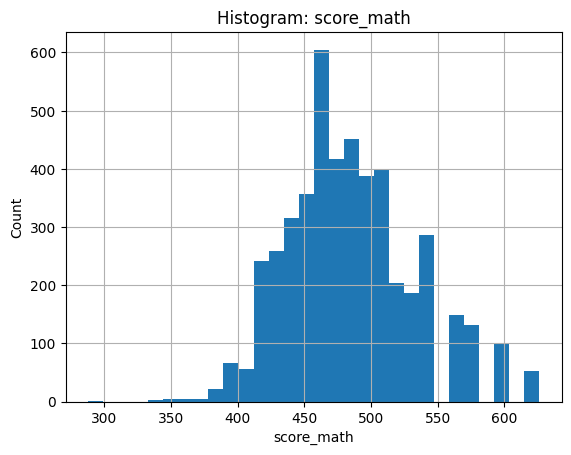

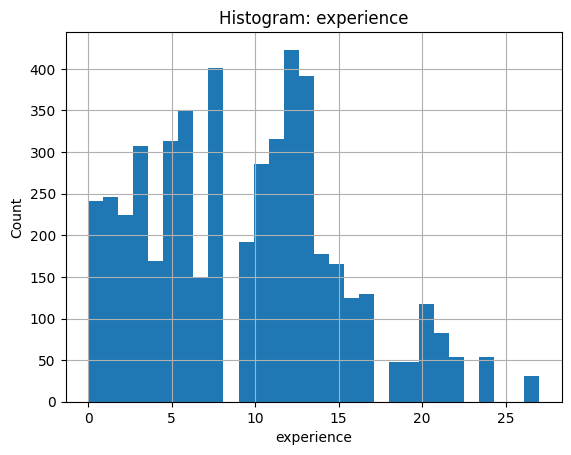

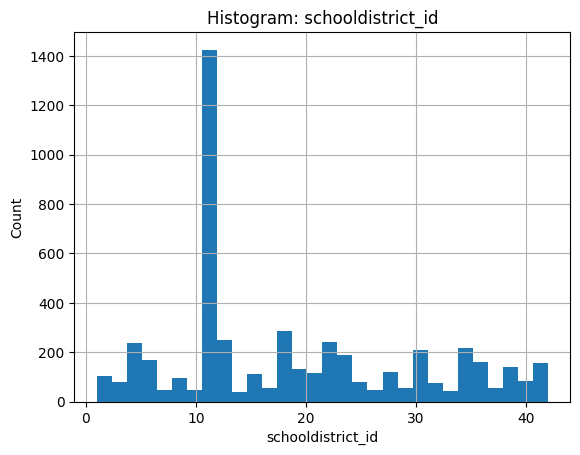

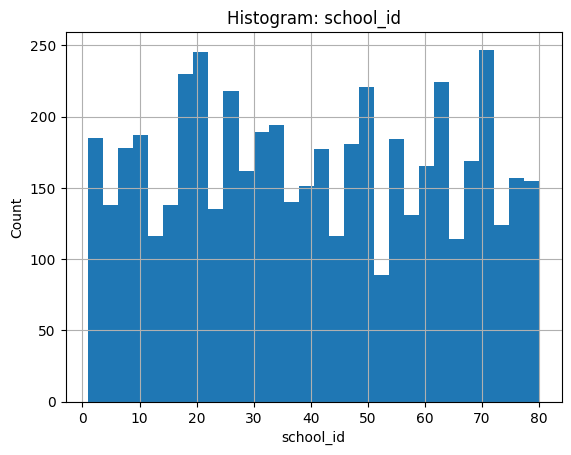

,mean,std,count
gender,,,
female,439.305519,32.105162,2265
male,433.383095,30.357400,2378


,mean,std,count
birth,,,
1981 Q4,509.500000,62.932504,2
1981 Q1,497.500000,7.778175,2
1981 Q3,442.000000,NaN,1
1979 Q4,441.937574,32.883616,849
1980 Q1,439.923556,33.692157,1125
1978 Q3,439.500000,4.949747,2
1980 Q4,435.413043,26.147085,46
1980 Q2,435.392986,29.714956,1112
1979 Q3,432.751724,27.907718,145


,mean,std,count
lunch,,,
non-free,444.578283,33.376799,2376
free,427.493783,26.452399,2252


,mean,std,count
ethnicity,,,
hispanic,453.750000,36.872528,4
asian,444.363636,45.712739,11
cauc,439.980192,31.918775,3130
other,436.000000,35.658099,5
afam,428.425218,28.473070,1491
amindian,404.500000,13.435029,2


,mean,std,count
class_type,,,
small,439.881124,32.380571,1388
regular+aide,435.035998,30.819008,1639
regular,434.426361,30.766405,1616


...

,mean,std,count
class_type,,,
small,490.527363,50.133085,1407
regular,482.825795,47.386325,1636
regular+aide,482.811786,45.430592,1663


,mean,std,count
school,,,
suburban,492.872464,44.072224,1035
rural,487.943917,47.593875,2211
urban,486.245863,44.431811,423
inner-city,470.918033,49.679164,1037


,mean,std,count
degree,,,
specialist,514.100000,49.574987,30
master,485.523232,47.803523,1485
bachelor,484.904840,47.541423,3058
master+,480.640351,49.081498,114


,mean,std,count
ladder,,,
level3,511.097561,50.860989,41
level2,500.177778,50.141503,90
level1,486.642591,47.621619,3489
probation,482.711790,51.530990,229
apprentice,480.281330,47.239571,391


,mean,std,count
t_ethnicity,,,
cauc,485.761978,47.357971,3924
afam,482.278689,49.656097,732


In [ ]:
# --- EDA: structure, missingness, distributions ---
import matplotlib.pyplot as plt

print("\nDtypes:\n", db_sample.dtypes)
print("\nMissing (count):\n", db_sample.isna().sum())

# Numeric variable histograms
num_cols = db_sample.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    db_sample[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Simple bivariate: score vs selected categorical predictors (mean ± std)
cat_cols = db_sample.select_dtypes(exclude=[np.number]).columns.tolist()
target_cols = [c for c in num_cols if c.startswith("score")]
for t in target_cols:
    for c in cat_cols:
        try:
            grp = db_sample.groupby(c)[t].agg(['mean','std','count']).sort_values('mean', ascending=False)
            display(grp.head(10))
        except Exception as e:
            print(f"Skip {c} for {t}: {e}")

/tmp/ipython-input-590710166.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='class_type', y='score_read', data=db_sample, estimator='mean', ci='sd')


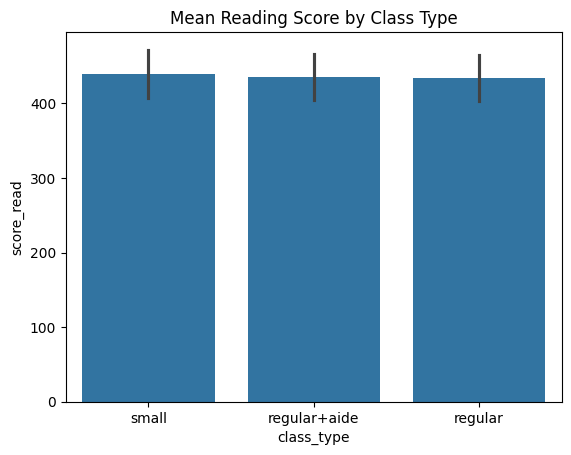

/tmp/ipython-input-590710166.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='class_type', y='score_math', data=db_sample, estimator='mean', ci='sd')


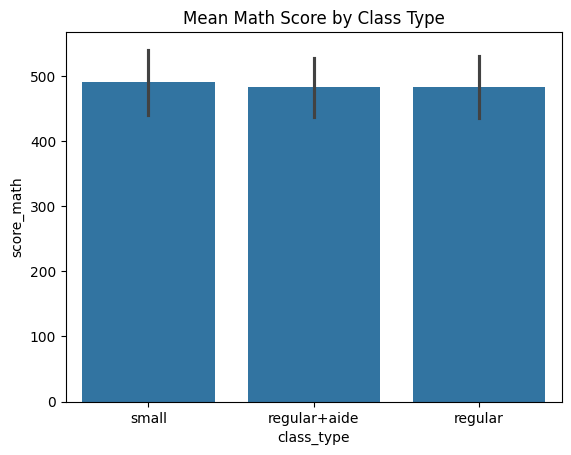

In [ ]:
sns.barplot(x='class_type', y='score_read', data=db_sample, estimator='mean', ci='sd')
plt.title('Mean Reading Score by Class Type')
plt.show()

sns.barplot(x='class_type', y='score_math', data=db_sample, estimator='mean', ci='sd')
plt.title('Mean Math Score by Class Type')
plt.show()


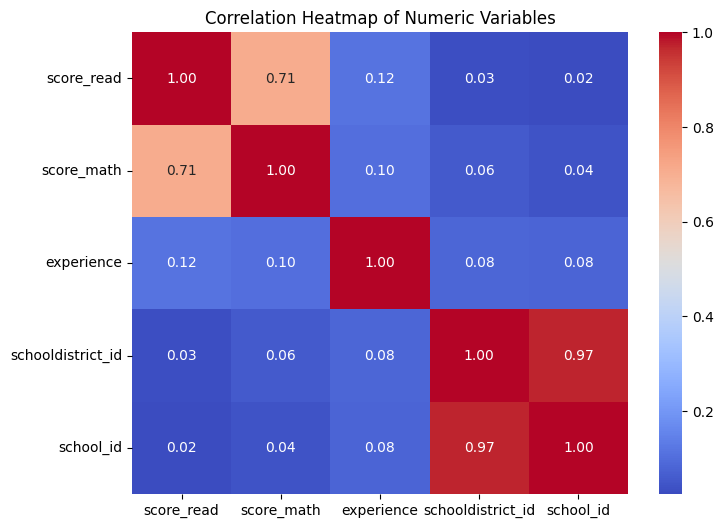

In [ ]:
import seaborn as sns

corr = db_sample.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


In [ ]:
# --- Preprocessing & modeling setup ---
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.impute import SimpleImputer

# Targets
y_cols = ["score_read", "score_math"]
X = db_sample.drop(columns=y_cols)
y = db_sample[y_cols].copy()

# Column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Preprocessors
num_tf = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_tf = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[("num", num_tf, num_cols), ("cat", cat_tf, cat_cols)],
    remainder="drop"
)

# Define base KFold and scorer that averages read & math MSE (to align with assignment metric)
def dual_mse(y_true, y_pred):
    return np.mean((y_pred - y_true)**2)

dual_mse_scorer = make_scorer(dual_mse, greater_is_better=False)  # negative for sklearn convention

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

In [ ]:
# --- Define and evaluate candidate models ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

candidates = {}

# 1) OLS (linear regression) per target wrapped as multi-output
candidates["ols"] = Pipeline(steps=[("prep", preprocessor),
                                    ("reg", MultiOutputRegressor(LinearRegression(n_jobs=None)))])
# 2) Ridge (alpha tuned grid)
candidates["ridge"] = Pipeline(steps=[("prep", preprocessor),
                                      ("reg", MultiOutputRegressor(Ridge(alpha=1.0)))])

# 3) Lasso
candidates["lasso"] = Pipeline(steps=[("prep", preprocessor),
                                      ("reg", MultiOutputRegressor(Lasso(alpha=0.001, max_iter=5000)))])
# 4) Random Forest
candidates["rf"] = Pipeline(steps=[("prep", preprocessor),
                                   ("reg", MultiOutputRegressor(RandomForestRegressor(
                                       n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)))])
# 5) Gradient Boosting
candidates["gbr"] = Pipeline(steps=[("prep", preprocessor),
                                    ("reg", MultiOutputRegressor(GradientBoostingRegressor(
                                        random_state=42)))])
# 6) MLP (neural net)
candidates["mlp"] = Pipeline(steps=[("prep", preprocessor),
                                    ("reg", MultiOutputRegressor(MLPRegressor(
                                        hidden_layer_sizes=(128,64),
                                        activation="relu",
                                        learning_rate_init=0.001,
                                        max_iter=500,
                                        random_state=42)))])

# Evaluate
cv_results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X, y, scoring=dual_mse_scorer, cv=cv, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: mean CV dual-MSE = {scores.mean():.4f}  (sd {scores.std():.4f})")

# Pick best by mean CV score (remember: more negative is worse since scorer is negative loss)
best_name = max(cv_results, key=lambda k: cv_results[k].mean())  # less negative is better -> max
print("\nSelected model:", best_name)

In [ ]:
# --- Fit selected model on full sample, evaluate on db_out (assignment metric) ---
best_model = candidates[best_name]
best_model.fit(X, y)

X_out = db_out.drop(columns=y_cols)
y_out = db_out[y_cols].copy()

y_pred_out = best_model.predict(X_out)

mse_out = np.mean((y_pred_out[:,0] - y_out["score_read"].values)**2 + (y_pred_out[:,1] - y_out["score_math"].values)**2) / 2.0
print("mse_out =", float(mse_out))

In [ ]:
# --- Interpretation: feature importances / coefficients & permutation importance ---
from sklearn.inspection import permutation_importance

# Get feature names after preprocessing
ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
num_features = num_cols
cat_features = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = np.array(num_features + cat_features)

# If linear-like, extract coefficients; otherwise use permutation importance
def try_linear_coeffs(mo_estimator):
    try:
        # MultiOutputRegressor holds estimators_ list, one per target
        coefs = []
        for est in mo_estimator.estimators_:
            if hasattr(est, "coef_"):
                c = est.coef_.ravel()
                coefs.append(c)
            else:
                return None
        return np.vstack(coefs)
    except Exception:
        return None

linear_coefs = try_linear_coeffs(best_model.named_steps["reg"])

if linear_coefs is not None:
    for i, t in enumerate(y_cols):
        order = np.argsort(np.abs(linear_coefs[i]))[::-1][:20]
        top = pd.DataFrame({"feature": feature_names[order], "coef": linear_coefs[i][order]})
        print(f"Top coefficients for {t}:")
        display(top)
else:
    r = permutation_importance(best_model, X, y, scoring=dual_mse_scorer, n_repeats=5, random_state=42, n_jobs=-1)
    order = np.argsort(r.importances_mean)[::-1][:20]
    top = pd.DataFrame({"feature": feature_names[order],
                        "importance_mean": r.importances_mean[order],
                        "importance_std": r.importances_std[order]})
    print("Top permutation importances (dual-MSE):")
    display(top)

In [ ]:
# --- Diagnostics: residual analysis on training data ---
import matplotlib.pyplot as plt

y_pred_in = best_model.predict(X)
resid_read = y["score_read"].values - y_pred_in[:,0]
resid_math = y["score_math"].values - y_pred_in[:,1]

for resid, t in zip([resid_read, resid_math], y_cols):
    plt.figure()
    plt.hist(resid, bins=40)
    plt.title(f"Residual histogram: {t}")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.show()

### References & AI Use
- Chetty, R., Friedman, J. N., Hilger, N., Saez, E., Schanzenbach, D. W., & Yagan, D. (2011). *How Does Your Kindergarten Classroom Affect Your Earnings? Evidence from Project STAR.*
- UNSW AI Referencing guidance: https://www.unsw.edu.au/student/managing-your-studies/academic-skills-support/toolkit/referencing/ai-referencing

This notebook’s scaffolding and comments were assisted by an AI writing tool. All analysis decisions, parameter choices, and interpretations should be reviewed, verified, and expanded by the authors.